In [1]:
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, make_scorer, f1_score, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import ADASYN
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. Carregamento e seleção de features
df = pd.read_csv("../datasets/spotify_processed.csv")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
# Usando a estratégia de Seleção de Features que identificamos como promissora
top_features = [
    'instrumentalness', 'acousticness', 'duration_ms', 'valence', 'energy',
    'loudness', 'liveness', 'tempo', 'danceability', 'speechiness'
]
# Criando a variável alvo e o conjunto de features X
X = df[top_features]
y = df['is_popular']
# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# 3. Criação do pipeline e busca de hiperparâmetros para o XGBoost
f1_scorer_popular = make_scorer(f1_score, pos_label=1)
pipeline_xgb = ImbPipeline([
    ('sampler', ADASYN(random_state=42)),
    ('classifier', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
param_grid_xgb = {
    'sampler': [ADASYN(random_state=42), SMOTEENN(random_state=42)],
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 7],
    'classifier__learning_rate': [0.1, 0.2]
}
grid_search = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    scoring=f1_scorer_popular,
    cv=3,
    n_jobs=-1,
    verbose=2
)
print("\nIniciando a otimização do XGBoost...")
grid_search.fit(X_train, y_train)


Iniciando a otimização do XGBoost...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


e:\Faculdade\PISI3\projetodb\PISI3\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:09:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('sampler', ADASYN(random_state=42)),
                                       ('classifier',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='logloss',
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma...
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.1, 0.2],
                         'classifier__max_depth': [5, 7],
                         'classifier__n_estimators': [100, 200],
                         'sampler': [ADASYN(random_state=42),
                                     SMOTEENN(random_state=42)]},
             scoring=make_scorer(f1_score, response_method='predict', pos_label=1),
             verbose=2)


Melhores parâmetros encontrados: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'sampler': SMOTEENN(random_state=42)}
Melhor F1-score (durante validação cruzada): 0.2862

--- Relatório de Classificação (XGBoost Otimizado no Treino) ---
              precision    recall  f1-score   support

           0       0.99      0.68      0.81     57809
           1       0.26      0.94      0.41      7036

    accuracy                           0.71     64845
   macro avg       0.63      0.81      0.61     64845
weighted avg       0.91      0.71      0.77     64845



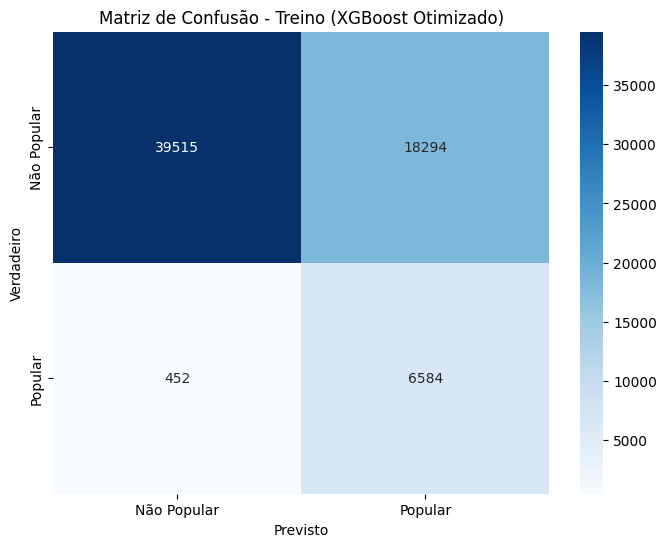


--- Relatório de Classificação (XGBoost Otimizado no Teste) ---
              precision    recall  f1-score   support

           0       0.94      0.64      0.76     14453
           1       0.18      0.66      0.29      1759

    accuracy                           0.64     16212
   macro avg       0.56      0.65      0.52     16212
weighted avg       0.86      0.64      0.71     16212



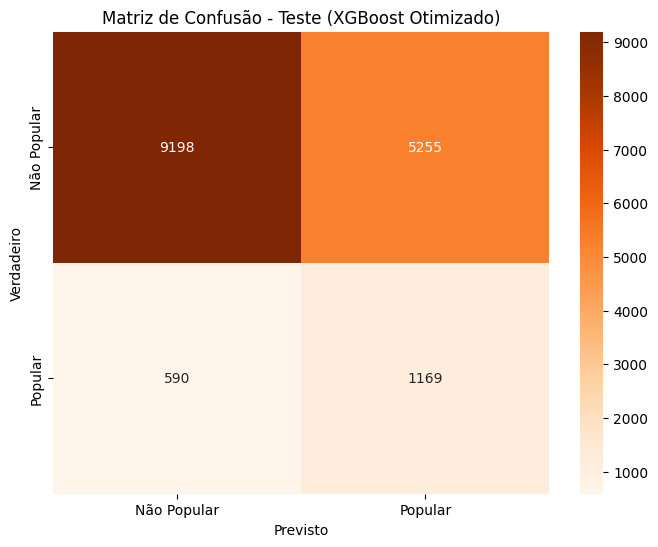

In [5]:
# 4. Avaliação do modelo
print(f"\nMelhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1-score (durante validação cruzada): {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
print("\n--- Relatório de Classificação (XGBoost Otimizado no Treino) ---")
y_pred_train = best_model.predict(X_train)
print(classification_report(y_train, y_pred_train))
cm_train = confusion_matrix(y_train, y_pred_train)
fig_train, ax_train = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax_train, xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'])
ax_train.set_title('Matriz de Confusão - Treino (XGBoost Otimizado)')
ax_train.set_ylabel('Verdadeiro')
ax_train.set_xlabel('Previsto')
plt.show()
print("\n--- Relatório de Classificação (XGBoost Otimizado no Teste) ---")
y_pred_test = best_model.predict(X_test)
print(classification_report(y_test, y_pred_test))
cm_test = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=ax, xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'])
ax.set_title('Matriz de Confusão - Teste (XGBoost Otimizado)')
ax.set_ylabel('Verdadeiro')
ax.set_xlabel('Previsto')
plt.show()

In [7]:
import os

In [8]:
# 5. Salvando o modelo com Pickle
print("\nSalvando o melhor modelo encontrado...")
pasta_destino = "../modelos"
os.makedirs(pasta_destino, exist_ok=True)
nome_arquivo = 'modelo_xgboost_otimizado.pkl'
caminho_completo = os.path.join(pasta_destino, nome_arquivo)
with open(caminho_completo, 'wb') as file:
    pickle.dump(best_model, file)
print("Modelo salvo com sucesso como 'modelo_xgboost_otimizado.pkl'")


Salvando o melhor modelo encontrado...
Modelo salvo com sucesso como 'modelo_xgboost_otimizado.pkl'
